In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
monkey = "M1"
phase = 1
stim = "Lf" #"Hf"

snr_choice = 0.8
snr_choice_list = [0.65, 0.8, 1.0]
choice = "ensemble"

readout_weight_list = []
class_imbalance_list = []
readout_weight_real_list = []
readout_weights_sum_list = []
readout_weights_diff_list = []
cp_list = []
cp_real_list = []
evec_list = []
for seed in range(1,12):
    for snr_choice in snr_choice_list:
        readout_weights = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + str(snr_choice) + "_choice_" + choice + "_readout_weights_vh.npy")
        class_imbalance = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + str(snr_choice) + "_choice_" + choice + "_class_imbalance_vh.npy")
        readout_weights_real = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + str(snr_choice) + "_choice_" + choice + "_readout_weights_real.npy")
        readout_weights_sum = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + str(snr_choice) + "_choice_" + choice + "_readout_weights_sum.npy")
        readout_weights_diff = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + str(snr_choice) + "_choice_" + choice + "_readout_weights_diff.npy")
        cp = np.load("results/" + monkey + "_Phase" +str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + str(snr_choice) + "_choice_" + choice + "_cp.npy")
        cp_real = np.load("results/" + monkey + "_Phase" +str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + str(snr_choice) + "_choice_" + choice + "_cp_real.npy")

        eigenvector = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + str(snr_choice) + "_choice_" + choice + "_eigenvector_vh.npy")

        neurons_tuned_rad = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + str(stim) + "_gratings_seed_" + str(seed) + "_snr_choice_" + str(snr_choice) + "_choice_" + choice + "_neurons_tuned_rad.npy")
        neurons_tuned_circ = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + str(stim) + "_gratings_seed_" + str(seed) + "_snr_choice_" + str(snr_choice) + "_choice_" + choice + "_neurons_tuned_circ.npy")

        #print(readout_weights)
        if (readout_weights != np.array('NaN')).sum() != 0:
            readout_weight_list.append(readout_weights)
            cp_list.append(cp)
        class_imbalance_list.append(class_imbalance)
        if (readout_weights_real != np.array('NaN')).sum() != 0:
            readout_weight_real_list.append(readout_weights_real)
            cp_real_list.append(cp_real)
        if (readout_weights_sum != np.array('NaN')).sum() != 0:
            readout_weights_sum_list.append(readout_weights_sum)
        if (readout_weights_diff != np.array('NaN')).sum() != 0:
            readout_weights_diff_list.append(readout_weights_diff)
            
        evec_list.append(eigenvector)
    
readout_weight_list = np.stack(readout_weight_list)
class_imbalance_list = np.stack(class_imbalance_list)
readout_weight_real_list = np.stack(readout_weight_real_list)
readout_weights_sum_list = np.stack(readout_weights_sum_list)
evec_list = np.stack(evec_list)
#readout_weights_diff_list = np.stack(readout_weights_diff_list)
cp_list = np.stack(cp_list)
cp_real_list = np.stack(cp_real_list)

len(neurons_tuned_circ)

In [ ]:
readout_weight_real_list

In [ ]:
class_imbalance_mean = class_imbalance_list.mean(0)
class_imbalance_std = class_imbalance_list.std(0)

readout_weight_mean = readout_weight_list.mean(0)
readout_weight_std = readout_weight_list.std(0)

readout_weight_real_mean = readout_weight_real_list.mean(0)
readout_weight_real_std = readout_weight_real_list.std(0)

readout_weights_sum_mean = readout_weights_sum_list.mean(0)
readout_weights_sum_std = readout_weights_sum_list.std(0)

#readout_weights_diff_mean = readout_weights_diff_list.mean(0)
#readout_weights_diff_std = readout_weights_diff_list.std(0)


In [ ]:
plt.plot([0.1, 0.3, 0.5, 0.75, 0.9], class_imbalance_mean/800, "-*")
plt.xlabel("probability of inactivation")
plt.ylabel("class imbalance")

In [ ]:
plt.bar(["circular neurons", "radial neurons"], [readout_weight_mean[:len(neurons_tuned_circ)].mean(), readout_weight_mean[len(neurons_tuned_circ):].mean()])
plt.ylabel("Readout weights")

plt.figure()
plt.bar(["circular neurons", "radial neurons"], [cp_list[:,:len(neurons_tuned_circ)].mean()-0.5, cp_list[:,len(neurons_tuned_circ):].mean()-0.5])
plt.ylabel("Choice probabilities")


In [ ]:
readout_weight_mean

In [ ]:
plt.figure()
plt.hist(readout_weight_list[:,:len(neurons_tuned_circ)].flatten())

plt.figure()
plt.hist(readout_weight_list[:,len(neurons_tuned_circ):].flatten())

In [ ]:

plt.bar(["circular neurons", "radial neurons"], [readout_weight_real_mean[:len(neurons_tuned_circ)].mean(), readout_weight_real_mean[len(neurons_tuned_circ):].mean()])
plt.ylabel("Readout weights")

plt.figure()
plt.bar(["circular neurons", "radial neurons"], [cp_real_list[:,:len(neurons_tuned_circ)].mean()-0.5, cp_real_list[:,len(neurons_tuned_circ):].mean()-0.5])
plt.ylabel("Choice probabilities")
"""
#Monkey 1
readout_weight_real_circ = (readout_weight_real_list[0,:len(neurons_tuned_circ)].mean() + (-readout_weight_real_list[1,:len(neurons_tuned_circ)].mean() ) + (-readout_weight_real_list[2,:len(neurons_tuned_circ)].mean() + (-readout_weight_real_list[3,:len(neurons_tuned_circ)].mean()) + (-readout_weight_real_list[4,:len(neurons_tuned_circ)].mean() ) + (-readout_weight_real_list[5,:len(neurons_tuned_circ)].mean()) + readout_weight_real_list[6, :len(neurons_tuned_circ)].mean() + readout_weight_real_list[7,:len(neurons_tuned_circ)].mean() + (-readout_weight_real_list[8,:len(neurons_tuned_circ)].mean() ) + readout_weight_real_list[9,:len(neurons_tuned_circ)].mean() + (-readout_weight_real_list[10,:len(neurons_tuned_circ)].mean() )))/11
readout_weight_real_rad = (readout_weight_real_list[0,len(neurons_tuned_circ):].mean() + (-readout_weight_real_list[1,len(neurons_tuned_circ):].mean() ) + (-readout_weight_real_list[2,len(neurons_tuned_circ):].mean() + (-readout_weight_real_list[3,len(neurons_tuned_circ):].mean()) + (-readout_weight_real_list[4,len(neurons_tuned_circ):].mean() ) + (-readout_weight_real_list[5,len(neurons_tuned_circ):].mean()) + readout_weight_real_list[6, len(neurons_tuned_circ):].mean() + readout_weight_real_list[7,len(neurons_tuned_circ):].mean() + (-readout_weight_real_list[8,len(neurons_tuned_circ):].mean() ) + readout_weight_real_list[9,len(neurons_tuned_circ):].mean() + (-readout_weight_real_list[10,len(neurons_tuned_circ):].mean() )))/11

#Monkey 2
#readout_weight_real_circ = (readout_weight_real_list[0,:len(neurons_tuned_circ)].mean() + (readout_weight_real_list[1,:len(neurons_tuned_circ)].mean() ) + (-readout_weight_real_list[2,:len(neurons_tuned_circ)].mean() + (readout_weight_real_list[3,:len(neurons_tuned_circ)].mean()) + (readout_weight_real_list[4,:len(neurons_tuned_circ)].mean() ) + (readout_weight_real_list[5,:len(neurons_tuned_circ)].mean()) + readout_weight_real_list[6, :len(neurons_tuned_circ)].mean() + readout_weight_real_list[7,:len(neurons_tuned_circ)].mean() + (-readout_weight_real_list[8,:len(neurons_tuned_circ)].mean() ) + readout_weight_real_list[9,:len(neurons_tuned_circ)].mean() + (readout_weight_real_list[10,:len(neurons_tuned_circ)].mean() )))/11
#readout_weight_real_rad = (readout_weight_real_list[0,len(neurons_tuned_circ):].mean() + (readout_weight_real_list[1,len(neurons_tuned_circ):].mean() ) + (-readout_weight_real_list[2,len(neurons_tuned_circ):].mean() + (readout_weight_real_list[3,len(neurons_tuned_circ):].mean()) + (readout_weight_real_list[4,len(neurons_tuned_circ):].mean() ) + (readout_weight_real_list[5,len(neurons_tuned_circ):].mean()) + readout_weight_real_list[6, len(neurons_tuned_circ):].mean() + readout_weight_real_list[7,len(neurons_tuned_circ):].mean() + (-readout_weight_real_list[8,len(neurons_tuned_circ):].mean() ) + readout_weight_real_list[9,len(neurons_tuned_circ):].mean() + (readout_weight_real_list[10,len(neurons_tuned_circ):].mean() )))/11

cp_real_list = cp_real_list - 0.5

#Monkey 1
cp_real_circ = (cp_real_list[0,:len(neurons_tuned_circ)].mean() + (-cp_real_list[1,:len(neurons_tuned_circ)].mean() ) + (-cp_real_list[2,:len(neurons_tuned_circ)].mean() + (-cp_real_list[3,:len(neurons_tuned_circ)].mean()) + (-cp_real_list[4,:len(neurons_tuned_circ)].mean() ) + (-cp_real_list[5,:len(neurons_tuned_circ)].mean()) + cp_real_list[6, :len(neurons_tuned_circ)].mean() + cp_real_list[7,:len(neurons_tuned_circ)].mean() + (-cp_real_list[8,:len(neurons_tuned_circ)].mean() ) + cp_real_list[9,:len(neurons_tuned_circ)].mean() + (-cp_real_list[10,:len(neurons_tuned_circ)].mean() )))/11
cp_real_rad = (cp_real_list[0,len(neurons_tuned_circ):].mean() + (-cp_real_list[1,len(neurons_tuned_circ):].mean() ) + (-cp_real_list[2,len(neurons_tuned_circ):].mean() + (-cp_real_list[3,len(neurons_tuned_circ):].mean()) + (-cp_real_list[4,len(neurons_tuned_circ):].mean() ) + (-cp_real_list[5,len(neurons_tuned_circ):].mean()) + cp_real_list[6, len(neurons_tuned_circ):].mean() + cp_real_list[7,len(neurons_tuned_circ):].mean() + (-cp_real_list[8,len(neurons_tuned_circ):].mean() ) + cp_real_list[9,len(neurons_tuned_circ):].mean() + (-cp_real_list[10,len(neurons_tuned_circ):].mean() )))/11

#Monkey 2
#cp_real_circ = (cp_real_list[0,:len(neurons_tuned_circ)].mean() + (cp_real_list[1,:len(neurons_tuned_circ)].mean() ) + (-cp_real_list[2,:len(neurons_tuned_circ)].mean() + (cp_real_list[3,:len(neurons_tuned_circ)].mean()) + (cp_real_list[4,:len(neurons_tuned_circ)].mean() ) + (cp_real_list[5,:len(neurons_tuned_circ)].mean()) + cp_real_list[6, :len(neurons_tuned_circ)].mean() + cp_real_list[7,:len(neurons_tuned_circ)].mean() + (-cp_real_list[8,:len(neurons_tuned_circ)].mean() ) + cp_real_list[9,:len(neurons_tuned_circ)].mean() + (cp_real_list[10,:len(neurons_tuned_circ)].mean() )))/11
#cp_real_rad = (cp_real_list[0,len(neurons_tuned_circ):].mean() + (cp_real_list[1,len(neurons_tuned_circ):].mean() ) + (-cp_real_list[2,len(neurons_tuned_circ):].mean() + (cp_real_list[3,len(neurons_tuned_circ):].mean()) + (cp_real_list[4,len(neurons_tuned_circ):].mean() ) + (cp_real_list[5,len(neurons_tuned_circ):].mean()) + cp_real_list[6, len(neurons_tuned_circ):].mean() + cp_real_list[7,len(neurons_tuned_circ):].mean() + (-cp_real_list[8,len(neurons_tuned_circ):].mean() ) + cp_real_list[9,len(neurons_tuned_circ):].mean() + (cp_real_list[10,len(neurons_tuned_circ):].mean() )))/11

plt.bar(["circular neurons", "radial neurons"], [readout_weight_real_circ, readout_weight_real_rad])
plt.ylabel("readout weights")
plt.title("Data results (ensemble, sign matched)")

plt.figure()
plt.bar(["circular neurons", "radial neurons"], [cp_real_circ, cp_real_rad])
plt.ylabel("choice probabilities")
plt.title("Data results (ensemble, sign matched)")
"""

In [ ]:
plt.bar(["circular neurons", "radial neurons"], [readout_weights_sum_mean[:len(neurons_tuned_circ)].mean(), readout_weights_sum_mean[len(neurons_tuned_circ):].mean()])
plt.ylabel("Readout weights")
plt.title("(hard-coded) sum model")

In [ ]:
plt.bar(["circular neurons", "radial neurons"], [readout_weights_diff_mean[:len(neurons_tuned_circ)].mean(), readout_weights_diff_mean[len(neurons_tuned_circ):].mean()])


In [ ]:
for i in range(11):
    plt.figure()
    plt.bar(["circular neurons", "radial neurons"], [readout_weight_real_list[i,:len(neurons_tuned_circ)].mean(), readout_weight_real_list[i,len(neurons_tuned_circ):].mean()])
    #plt.bar(["circular neurons", "radial neurons"], [cp_real_list[i,:len(neurons_tuned_circ)].mean()-0.5, cp_real_list[i,len(neurons_tuned_circ):].mean()-0.5])
    plt.title(str(i))

In [ ]:
readout_weight_real_circ = (readout_weight_real_list[0,:len(neurons_tuned_circ)].mean() + (readout_weight_real_list[1,:len(neurons_tuned_circ)].mean() ) + (-readout_weight_real_list[2,:len(neurons_tuned_circ)].mean() + (readout_weight_real_list[3,:len(neurons_tuned_circ)].mean()) + (readout_weight_real_list[4,:len(neurons_tuned_circ)].mean() ) + (readout_weight_real_list[5,:len(neurons_tuned_circ)].mean()) + readout_weight_real_list[6, :len(neurons_tuned_circ)].mean() + readout_weight_real_list[7,:len(neurons_tuned_circ)].mean() + (-readout_weight_real_list[8,:len(neurons_tuned_circ)].mean() ) + readout_weight_real_list[9,:len(neurons_tuned_circ)].mean() + (readout_weight_real_list[10,:len(neurons_tuned_circ)].mean() )))/11
readout_weight_real_rad = (readout_weight_real_list[0,len(neurons_tuned_circ):].mean() + (readout_weight_real_list[1,len(neurons_tuned_circ):].mean() ) + (-readout_weight_real_list[2,len(neurons_tuned_circ):].mean() + (readout_weight_real_list[3,len(neurons_tuned_circ):].mean()) + (readout_weight_real_list[4,len(neurons_tuned_circ):].mean() ) + (readout_weight_real_list[5,len(neurons_tuned_circ):].mean()) + readout_weight_real_list[6, len(neurons_tuned_circ):].mean() + readout_weight_real_list[7,len(neurons_tuned_circ):].mean() + (-readout_weight_real_list[8,len(neurons_tuned_circ):].mean() ) + readout_weight_real_list[9,len(neurons_tuned_circ):].mean() + (readout_weight_real_list[10,len(neurons_tuned_circ):].mean() )))/11


In [ ]:
for i in range(11):
    plt.figure()
    plt.bar(["circular neurons", "radial neurons"], [readout_weight_list[i,:len(neurons_tuned_circ)].mean(), readout_weight_list[i,len(neurons_tuned_circ):].mean()])
    plt.title("seed " + str(i))

In [ ]:
for i in range(11):
    plt.figure()
    plt.bar(["circular neurons", "radial neurons"], [cp_list[i,:len(neurons_tuned_circ)].mean()-0.5, cp_list[i,len(neurons_tuned_circ):].mean()-0.5])
    

In [ ]:
cp.shape

In [ ]:
for i in range(5):
    plt.plot(evec_list[i])

In [ ]:
seed=1
cp = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + str(snr_choice) + "_choice_" + choice + "_cp.npy")


In [ ]:
cp

In [ ]:
monkey = "M1"
phase = 1
stim = "Lf" #"Hf"

snr_choice = 0.8
snr_choice_list = [0.65, 0.8, 1.0]
choice = "ensemble"

readout_weight_gd_list = []
class_imbalance_gd_list = []
cp_gd_list = []

for seed in range(1,12):
    for snr_choice in snr_choice_list:
        readout_weights = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_GD_seed_" + str(seed) + "_snr_choice_" + str(snr_choice) + "_choice_" + choice + "_readout_weights.npy")
        class_imbalance = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_GD_seed_" + str(seed) + "_snr_choice_" + str(snr_choice) + "_choice_" + choice + "_class_imbalance.npy")
        cp = np.load("results/" + monkey + "_Phase" +str(phase) + "_" + stim + "_gratings_GD_seed_" + str(seed) + "_snr_choice_" + str(snr_choice) + "_choice_" + choice + "_cp.npy")
    
        w_gd = np.load("results/" + monkey + "_Phase" +str(phase) + "_" + stim + "_gratings_GD_seed_" + str(seed) + "_snr_choice_" + str(snr_choice) + "_choice_" + choice + "w_gd.npy")
        b_gd = np.load("results/" + monkey + "_Phase" +str(phase) + "_" + stim + "_gratings_GD_seed_" + str(seed) + "_snr_choice_" + str(snr_choice) + "_choice_" + choice + "b_gd.npy")
        
        neurons_tuned_rad = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + str(stim) + "_gratings_seed_" + str(seed) + "_snr_choice_" + str(snr_choice) + "_choice_" + choice + "_neurons_tuned_rad.npy")
        neurons_tuned_circ = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + str(stim) + "_gratings_seed_" + str(seed) + "_snr_choice_" + str(snr_choice) + "_choice_" + choice + "_neurons_tuned_circ.npy")
    
        #print(readout_weights)
        if (readout_weights != np.array('NaN')).sum() != 0:
            readout_weight_gd_list.append(readout_weights)
            cp_gd_list.append(cp)
        class_imbalance_gd_list.append(class_imbalance)
            
readout_weight_gd_list = np.stack(readout_weight_gd_list)
class_imbalance_gd_list = np.stack(class_imbalance_gd_list)
cp_gd_list = np.stack(cp_gd_list)


In [ ]:
class_imbalance_gd_mean = class_imbalance_gd_list.mean(0)
class_imbalance_gd_std = class_imbalance_gd_list.std(0)

readout_weight_gd_mean = readout_weight_gd_list.mean(0)
readout_weight_gd_std = readout_weight_gd_list.std(0)

cp_gd_mean = cp_gd_list.mean(0)
cp_gd_std = cp_gd_list.std(0)

In [ ]:
plt.bar(["circular neurons", "radial neurons"], [readout_weight_gd_mean[:len(neurons_tuned_circ)].mean(), readout_weight_gd_mean[len(neurons_tuned_circ):].mean()])
plt.ylabel("readout weights")
plt.title("gradient descent")

plt.figure()
plt.bar(["circular neurons", "radial neurons"], [cp_gd_mean[:len(neurons_tuned_circ)].mean(), cp_gd_mean[len(neurons_tuned_circ):].mean()])
plt.ylabel("choice probability")
plt.title("gradient descent")

In [ ]:
plt.plot([.00001, 0.1, 0.3, 0.5, 0.75, 0.9], class_imbalance_gd_mean/200, "*-")
plt.ylabel("class imbalance")
plt.xlabel("probability inactivation")

In [ ]:
plt.plot(w_gd, "-*")
plt.xlabel("weight index")
plt.ylabel("weight value")
plt.title("weights (gradient descent)")

plt.figure()
plt.plot(w_gd[neurons_tuned_circ])
plt.plot(w_gd[neurons_tuned_rad])
plt.xlabel("weight index")
plt.ylabel("weight value")
plt.title("weights (gradient descent)")

In [ ]:
for i in range(11):
    plt.figure()
    plt.bar(["circular neurons", "radial neurons"], [readout_weight_gd_list[i,:len(neurons_tuned_circ)].mean(), readout_weight_gd_list[i,len(neurons_tuned_circ):].mean()])
    plt.title(str(i))
    

In [ ]:
#Monkey 1
#readout_weight_gd_circ = (readout_weight_gd_list[0,:len(neurons_tuned_circ)].mean() + (-readout_weight_gd_list[1,:len(neurons_tuned_circ)].mean() ) + (readout_weight_gd_list[2,:len(neurons_tuned_circ)].mean() + (readout_weight_gd_list[3,:len(neurons_tuned_circ)].mean()) + (-readout_weight_gd_list[4,:len(neurons_tuned_circ)].mean() ) + (-readout_weight_gd_list[5,:len(neurons_tuned_circ)].mean()) + (-readout_weight_gd_list[6, :len(neurons_tuned_circ)].mean()) + readout_weight_gd_list[7,:len(neurons_tuned_circ)].mean() + (readout_weight_gd_list[8,:len(neurons_tuned_circ)].mean() ) + readout_weight_gd_list[9,:len(neurons_tuned_circ)].mean() + (readout_weight_gd_list[10,:len(neurons_tuned_circ)].mean() )))/11
#readout_weight_gd_rad = (readout_weight_gd_list[0,len(neurons_tuned_circ):].mean() + (-readout_weight_gd_list[1,len(neurons_tuned_circ):].mean() ) + (readout_weight_gd_list[2,len(neurons_tuned_circ):].mean() + (readout_weight_gd_list[3,len(neurons_tuned_circ):].mean()) + (-readout_weight_gd_list[4,len(neurons_tuned_circ):].mean() ) + (-readout_weight_gd_list[5,len(neurons_tuned_circ):].mean()) + (-readout_weight_gd_list[6, len(neurons_tuned_circ):].mean()) + readout_weight_gd_list[7,len(neurons_tuned_circ):].mean() + (readout_weight_gd_list[8,len(neurons_tuned_circ):].mean() ) + readout_weight_gd_list[9,len(neurons_tuned_circ):].mean() + (readout_weight_gd_list[10,len(neurons_tuned_circ):].mean() )))/11

#Monkey 2
readout_weight_gd_circ = (-readout_weight_gd_list[0,:len(neurons_tuned_circ)].mean() + (readout_weight_gd_list[1,:len(neurons_tuned_circ)].mean() ) + (readout_weight_gd_list[2,:len(neurons_tuned_circ)].mean() + (readout_weight_gd_list[3,:len(neurons_tuned_circ)].mean()) + (-readout_weight_gd_list[4,:len(neurons_tuned_circ)].mean() ) + (readout_weight_gd_list[5,:len(neurons_tuned_circ)].mean()) + (-readout_weight_gd_list[6, :len(neurons_tuned_circ)].mean()) + readout_weight_gd_list[7,:len(neurons_tuned_circ)].mean() + (readout_weight_gd_list[8,:len(neurons_tuned_circ)].mean() ) + readout_weight_gd_list[9,:len(neurons_tuned_circ)].mean() + (readout_weight_gd_list[10,:len(neurons_tuned_circ)].mean() )))/11
readout_weight_gd_rad = (-readout_weight_gd_list[0,len(neurons_tuned_circ):].mean() + (readout_weight_gd_list[1,len(neurons_tuned_circ):].mean() ) + (readout_weight_gd_list[2,len(neurons_tuned_circ):].mean() + (readout_weight_gd_list[3,len(neurons_tuned_circ):].mean()) + (-readout_weight_gd_list[4,len(neurons_tuned_circ):].mean() ) + (readout_weight_gd_list[5,len(neurons_tuned_circ):].mean()) + (-readout_weight_gd_list[6, len(neurons_tuned_circ):].mean()) + readout_weight_gd_list[7,len(neurons_tuned_circ):].mean() + (readout_weight_gd_list[8,len(neurons_tuned_circ):].mean() ) + readout_weight_gd_list[9,len(neurons_tuned_circ):].mean() + (readout_weight_gd_list[10,len(neurons_tuned_circ):].mean() )))/11


plt.bar(["circular neurons", "radial neurons"], [readout_weight_gd_circ, readout_weight_gd_rad])


In [ ]:
for i in range(11):
    plt.figure()
    plt.bar(["circular neurons", "radial neurons"], [cp_gd_list[i,:len(neurons_tuned_circ)].mean()-0.5, cp_gd_list[i,len(neurons_tuned_circ):].mean()-0.5])
    plt.title(str(i))

In [31]:
monkey = "M1"
phase = 1
stim = "Lf" #"Hf"

snr_choice = 0.8
snr_choice_list = [0.65, 0.8, 1.0]
choice = "only_session"
session = 3

rw_list = []
rw_real_list = []
rw_train_list = []
rw_real_train_list = []
rw_sum_list = []
cp_list = []
cp_real_list = []
cp_train_list = []
cp_real_train_list = []
cp_sum_list = []
class_imbalance_list = []
class_imbalance_real_list = []
class_imbalance_train_list = []
class_imbalance_sum_list = []
eigenvector_list = []
weight_list = []
acc_list = []
acc_training_list = []

for seed in range(1,101):
    rw = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_[0.65, 0.8, 1.0]_choice_" + choice + "session_" + str(session) + "_readout_weights.npy")
    rw_real = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_[0.65, 0.8, 1.0]_choice_" + choice + "session_" + str(session) + "_readout_weights_real.npy")
    rw_sum = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_[0.65, 0.8, 1.0]_choice_" + choice + "session_" + str(session) + "_readout_weights_sum.npy")
    if rw.size != 1: rw_list.append(rw)
    if rw_real.size != 1: rw_real_list.append(rw_real)
    if rw_sum.size != 1: rw_sum_list.append(rw_sum)

    cp = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_[0.65, 0.8, 1.0]_choice_" + choice + "session_" + str(session) + "_cp.npy")
    cp_real = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_[0.65, 0.8, 1.0]_choice_" + choice + "session_" + str(session) + "_cp_real.npy") 
    #cp_sum = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_[0.65, 0.8, 1.0]_choice_" + choice + "session_10_cp_sum.npy") 
    if cp.size != 1: cp_list.append(cp)
    if cp_real.size != 1: cp_real_list.append(cp_real)
    #cp_sum_list.append(cp_sum)

    rw_train = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_[0.65, 0.8, 1.0]_choice_" + choice + "session_" + str(session) + "_readout_weights_train.npy")
    rw_real_train = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_[0.65, 0.8, 1.0]_choice_" + choice + "session_" + str(session) + "_readout_weights_real_total.npy")
    cp_train = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_[0.65, 0.8, 1.0]_choice_" + choice + "session_" + str(session) + "_cp_train.npy")
    cp_real_train = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_[0.65, 0.8, 1.0]_choice_" + choice + "session_" + str(session) + "_cp_real_total.npy") 
    if rw_train.size != 1: rw_train_list.append(rw_train)
    if rw_real_train.size != 1: rw_real_train_list.append(rw_real_train)
    if cp_train.size != 1: cp_train_list.append(cp_train)
    if cp_real_train.size != 1: cp_real_train_list.append(cp_real_train)
    
    eigenvector = np.load('results/' + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_[0.65, 0.8, 1.0]_choice_" + choice + "session_" + str(session) + "_eigenvector_vh.npy")
    eigenvector_list.append(eigenvector)
    
    weight = np.load('results/' + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_[0.65, 0.8, 1.0]_choice_" + choice + "session_" + str(session) + "_weight.npy")
    weight_list.append(weight)

    acc = np.load('results/' + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_[0.65, 0.8, 1.0]_choice_" + choice + "session_" + str(session) + "_acc.npy")
    acc_training = np.load('results/' + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_[0.65, 0.8, 1.0]_choice_" + choice + "session_" + str(session) + "_acc_training.npy")
    acc_list.append(acc); acc_training_list.append(acc_training)

    tuned_rad = np.load('results/' + monkey + '_Phase' + str(phase) + '_' + stim + '_gratings_seed_' + str(seed) + '_snr_choice_[0.65, 0.8, 1.0]_choice_' + choice + 'session_' + str(session) + '_neurons_tuned_rad.npy')
    tuned_circ = np.load('results/' + monkey + '_Phase' + str(phase) + '_' + stim + '_gratings_seed_' + str(seed) + '_snr_choice_[0.65, 0.8, 1.0]_choice_' + choice + 'session_' + str(session) + '_neurons_tuned_circ.npy')

    class_imbalance = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + stim +"_gratings_seed_" + str(seed) + "_snr_choice_[0.65, 0.8, 1.0]_choice_" + str(choice) + "session_" + str(session) + "_class_imbalance.npy")
    #class_imbalance_real = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + stim +"_gratings_seed_" + str(seed) + "_snr_choice_[0.65, 0.8, 1.0]_choice_" + str(choice) + "session_" + str(session) + "_class_imbalance_real.npy")
    class_imbalance_train = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + stim +"_gratings_seed_" + str(seed) + "_snr_choice_[0.65, 0.8, 1.0]_choice_" + str(choice) + "session_" + str(session) + "_class_imbalance_train.npy")
    class_imbalance_sum = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + stim +"_gratings_seed_" + str(seed) + "_snr_choice_[0.65, 0.8, 1.0]_choice_" + str(choice) + "session_" + str(session) + "_class_imbalance_sum.npy")
    
    class_imbalance_list.append(class_imbalance)
    class_imbalance_train_list.append(class_imbalance_train)
    #class_imbalance_real_list.append(class_imbalance_real)
    class_imbalance_sum_list.append(class_imbalance_sum)

rw_list = np.stack(rw_list)
rw_train_list = np.stack(rw_train_list)
rw_real_list = np.stack(rw_real_list) if rw_real_list!=[] else np.array(rw_real_list)
rw_real_train_list = np.stack(rw_real_train_list) if rw_real_train_list!=[] else np.array(rw_real_train_list)
rw_sum_list = np.stack(rw_sum_list)

cp_list = np.stack(cp_list)
cp_real_list = np.stack(cp_real_list)
cp_train_list = np.stack(cp_train_list)
cp_real_train_list = np.stack(cp_real_train_list)

eigenvector_list = np.stack(eigenvector_list)
weight_list = np.stack(weight_list)
acc_list = np.stack(acc_list)
acc_training_list = np.stack(acc_training_list)

class_imbalance_list = np.stack(class_imbalance_list)
class_imbalance_train_list = np.stack(class_imbalance_train_list)
#class_imbalance_real_list = np.stack(class_imbalance_real_list)
class_imbalance_sum_list = np.stack(class_imbalance_sum_list)

/tmp/ipykernel_2774713/3619713512.py:10: RuntimeWarning: Mean of empty slice.
  rw_real_train_mean = rw_real_train_list.mean(0)
/tmp/ipykernel_2774713/3619713512.py:22: RuntimeWarning: Mean of empty slice
  cp_real_train_mean = np.nanmean(cp_real_train_list, axis=0)
/tmp/ipykernel_2774713/3619713512.py:23: RuntimeWarning: Mean of empty slice
  cp_real_train_std = np.nanmean(cp_real_train_list, axis=0)


Text(0.5, 1.0, 'mean weights')

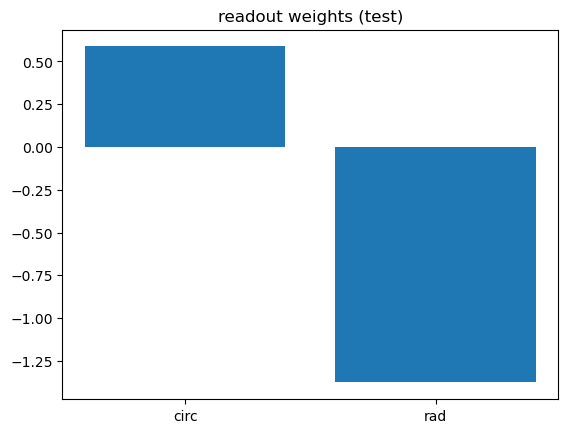

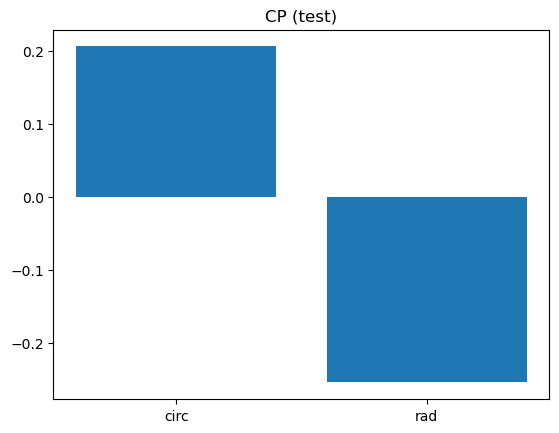

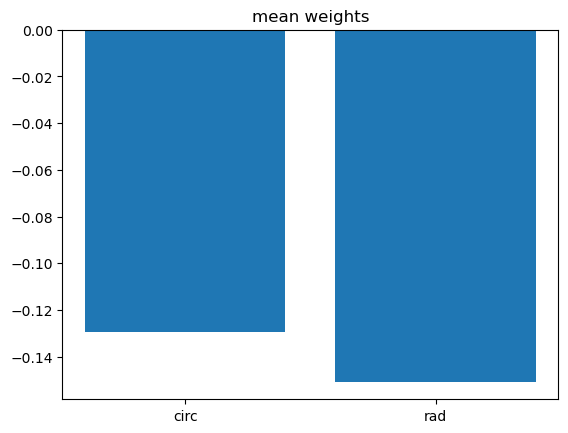

In [32]:
rw_mean = rw_list.mean(0)
rw_std = rw_list.std(0)

#rw_real_mean = rw_real_list.mean(0)
#rw_real_std = rw_real_list.std(0)

rw_train_mean = rw_train_list.mean(0)
rw_train_std = rw_train_list.std(0)

rw_real_train_mean = rw_real_train_list.mean(0)
rw_real_train_std = rw_real_train_list.std(0)

cp_mean = np.nanmean(cp_list,axis=0)
cp_std = np.nanstd(cp_list, axis=0)

cp_train_mean = np.nanmean(cp_train_list, axis=0)
cp_train_std = np.nanmean(cp_train_list, axis=0)

#cp_real_mean = cp_real_list.mean(0)
#cp_real_std = cp_real_list.std(0)

cp_real_train_mean = np.nanmean(cp_real_train_list, axis=0)
cp_real_train_std = np.nanmean(cp_real_train_list, axis=0)

weight_mean = weight_list.mean(0)
weight_std = weight_list.std(0)

plt.bar(["circ", "rad"], [rw_mean[:4].mean(), rw_mean[-1]])
plt.title("readout weights (test)")

plt.figure()
plt.bar(["circ", "rad"], [cp_mean[:4].mean()-0.5, cp_mean[-1]-0.5])
plt.title("CP (test)")

plt.figure()
plt.bar(["circ", "rad"], [weight_mean[:4].mean(), weight_mean[-1]])
plt.title("mean weights")

Text(0.5, 1.0, 'CP (train)')

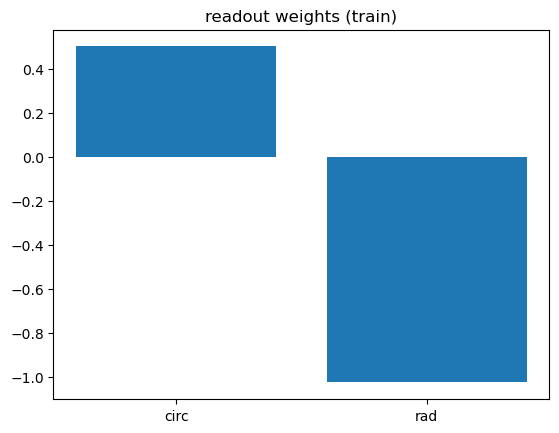

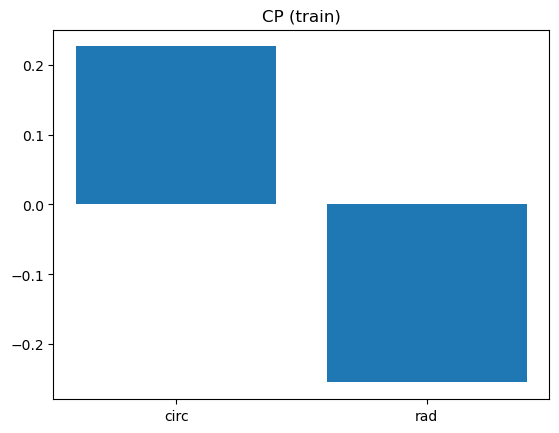

In [33]:
plt.bar(["circ", "rad"], [rw_train_mean[:4].mean(), rw_train_mean[-1]])
plt.title("readout weights (train)")

plt.figure()
plt.bar(["circ", "rad"], [cp_train_mean[:4].mean()-0.5, cp_train_mean[-1]-0.5])
plt.title("CP (train)")

In [43]:
"""
plt.figure()
plt.bar(["circ", "rad"], [rw_real_mean[:3].mean(), rw_real_mean[-1]])
plt.title("readout weights REAL (test)")

plt.figure()
plt.bar(["circ", "rad"], [cp_real_mean[:3].mean()-0.5, cp_real_mean[-1]-0.5])
plt.title("choice probability REAL (test)")
"""
plt.figure()
plt.bar(["circ", "rad"], [rw_real_train_mean[:4].mean(), rw_real_train_mean[-1]])
plt.title("readout weights REAL (train)")

plt.figure()
plt.bar(["circ", "rad"], [cp_real_train_mean[:4].mean()-0.5, cp_real_train_mean[-1]-0.5])
plt.title("choice probability REAL (train)")

IndexError: invalid index to scalar variable.

<Figure size 640x480 with 0 Axes>

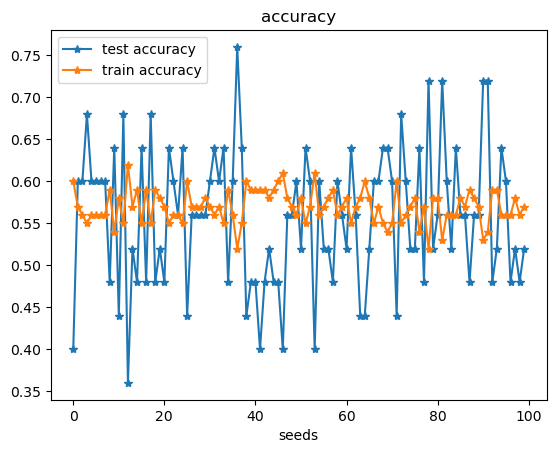

In [35]:
plt.plot(acc_list, "*-")
plt.plot(acc_training_list, "*-")
plt.xlabel("seeds")
plt.title("accuracy")
plt.legend(["test accuracy", "train accuracy"])

Text(0.5, 1.0, 'class imbalance (training set)')

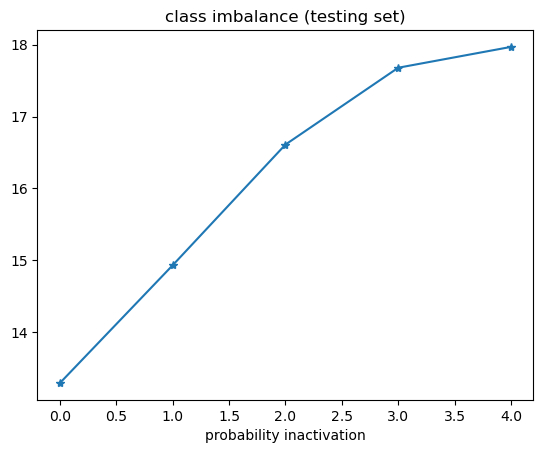

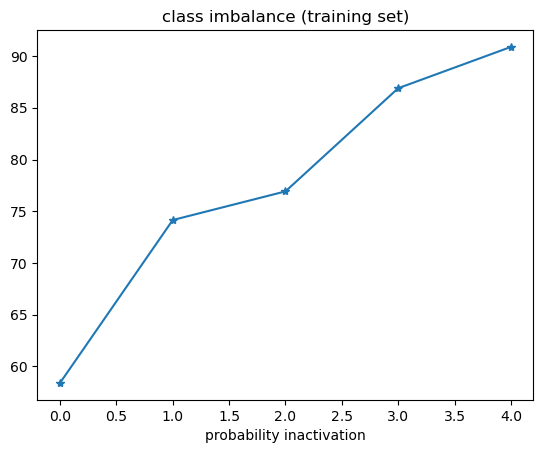

In [36]:
plt.figure()
plt.plot(class_imbalance_list.mean(0), "*-")
plt.xlabel("probability inactivation")
plt.title("class imbalance (testing set)")

plt.figure()
plt.plot(class_imbalance_train_list.mean(0), "*-")
plt.xlabel("probability inactivation")
plt.title("class imbalance (training set)")


In [37]:
for i in range(11):
    #plt.figure()
    #plt.plot(eigenvector_list[i,:])
    #plt.plot(weight_list[i,:])
    #plt.bar(["circ", "rad"], [cp_train_list[i,:3].mean(), cp_train_list[i,-1]])
    print("will plot here") if i==0 else print("")

will plot here












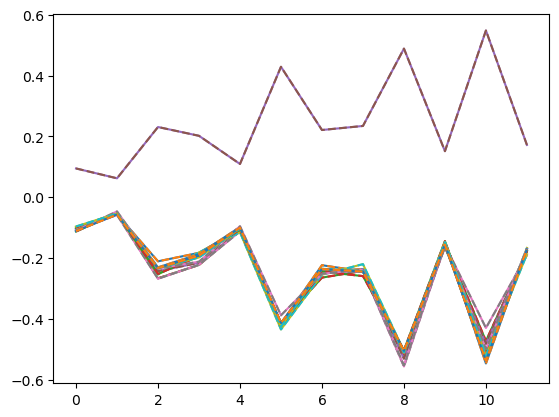

In [38]:
for i in range(11):
    plt.plot(weight_list[i,:])
    plt.plot(eigenvector_list[i,:], "--")

In [45]:
monkey = "M1"
phase = 1
stim = "Lf" #"Hf"

snr_choice = 0.8
snr_choice_list = [0.65, 0.8, 1.0]
choice = "only_session"
session = 3

readout_weight_gd_list = []
class_imbalance_gd_list = []
cp_gd_list = []
w_gd_list = []
b_gd_list = []
for seed in range(1,101):
    for snr_choice in snr_choice_list:
        readout_weights = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_GD_seed_" + str(seed) + "_snr_choice_" + str(snr_choice_list) + "_choice_" + choice + "_session"+ str(session) + "_readout_weights.npy")
        class_imbalance = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_GD_seed_" + str(seed) + "_snr_choice_" + str(snr_choice_list) + "_choice_" + choice + "_session"+ str(session) + "_class_imbalance.npy")
        cp = np.load("results/" + monkey + "_Phase" +str(phase) + "_" + stim + "_gratings_GD_seed_" + str(seed) + "_snr_choice_" + str(snr_choice_list) + "_choice_" + choice + "_session"+ str(session) + "_cp.npy")
    
        w_gd = np.load("results/" + monkey + "_Phase" +str(phase) + "_" + stim + "_gratings_GD_seed_" + str(seed) + "_snr_choice_" + str(snr_choice_list) + "_choice_" + choice + "_session"+ str(session) + "w_gd.npy")
        b_gd = np.load("results/" + monkey + "_Phase" +str(phase) + "_" + stim + "_gratings_GD_seed_" + str(seed) + "_snr_choice_" + str(snr_choice_list) + "_choice_" + choice + "_session"+ str(session) + "b_gd.npy")
        
        tuned_rad = np.load('results/' + monkey + '_Phase' + str(phase) + '_' + stim + '_gratings_seed_' + str(seed) + '_snr_choice_[0.65, 0.8, 1.0]_choice_' + choice + 'session_10_neurons_tuned_rad.npy')
        tuned_circ = np.load('results/' + monkey + '_Phase' + str(phase) + '_' + stim + '_gratings_seed_' + str(seed) + '_snr_choice_[0.65, 0.8, 1.0]_choice_' + choice + 'session_10_neurons_tuned_circ.npy')

        #print(readout_weights)
        if (readout_weights != np.array('NaN')).sum() != 0:
            readout_weight_gd_list.append(readout_weights)
            cp_gd_list.append(cp)
        class_imbalance_gd_list.append(class_imbalance)
        w_gd_list.append(w_gd)
        b_gd_list.append(b_gd)
        
readout_weight_gd_list = np.stack(readout_weight_gd_list)
class_imbalance_gd_list = np.stack(class_imbalance_gd_list)
cp_gd_list = np.stack(cp_gd_list)
w_gd_list = np.array(w_gd_list)
b_gd_list = np.array(b_gd_list)

In [46]:
readout_weight_gd_mean = readout_weight_gd_list.mean(0)
readout_weight_gd_std = readout_weight_gd_list.std(0)

cp_gd_mean = cp_gd_list.mean(0)
cp_gd_std = cp_gd_list.std(0)

class_imbalance_gd_mean = class_imbalance_gd_list.mean(0)
class_imbalance_gd_std = class_imbalance_gd_list.std(0)

<BarContainer object of 2 artists>

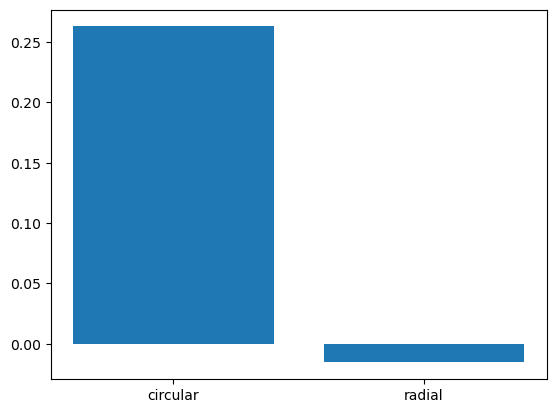

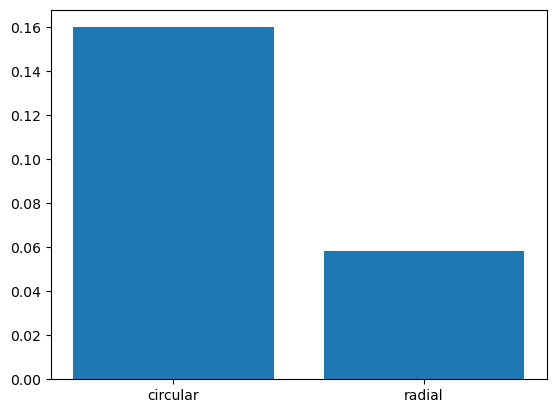

In [47]:
plt.bar(["circular", "radial"], [readout_weight_gd_mean[:4].mean(), readout_weight_gd_mean[-1].mean()])

plt.figure()
plt.bar(["circular", "radial"], [cp_gd_mean[:4].mean()-0.5, cp_gd_mean[-1].mean()-0.5])


Text(0.5, 1.0, 'class imbalance (testing set)')

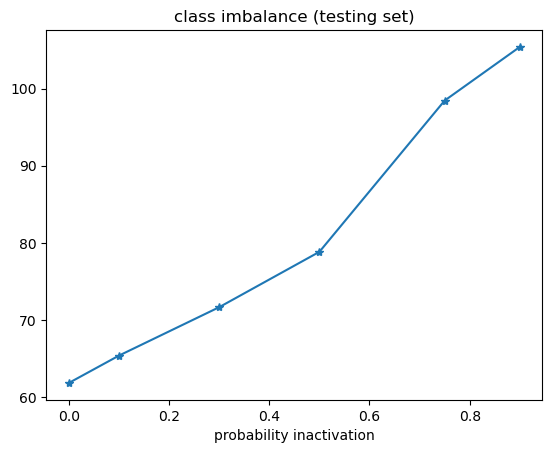

In [48]:
p_inactivation = [.00001, 0.1, 0.3, 0.5, 0.75, 0.9]

plt.figure()
plt.plot(p_inactivation, class_imbalance_gd_list.mean(0), "*-")
plt.xlabel("probability inactivation")
plt.title("class imbalance (testing set)")

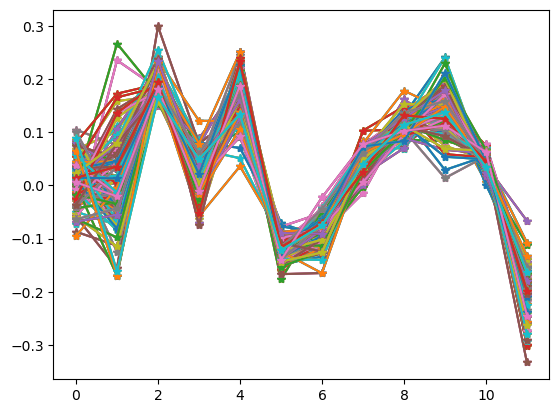

In [49]:
for i in range(len(w_gd_list)):
    plt.plot(w_gd_list[i,:], "*-")

Text(0, 0.5, 'biases')

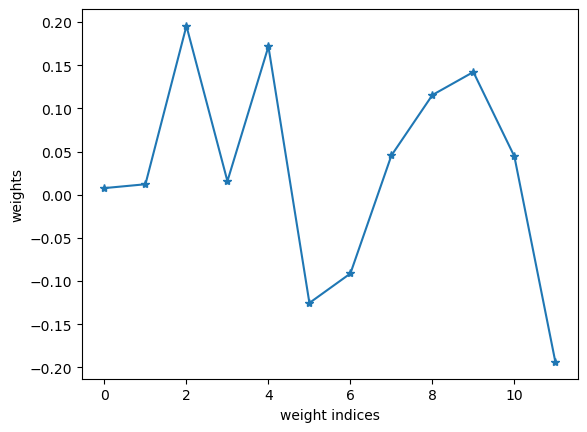

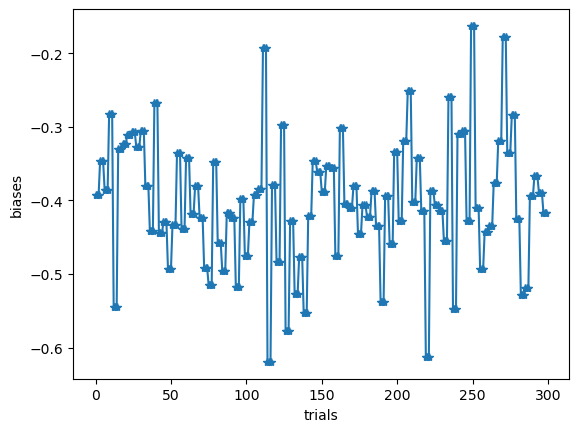

In [50]:
plt.plot(w_gd_list.mean(0), "*-")
plt.xlabel("weight indices")
plt.ylabel("weights")

plt.figure()
plt.plot(b_gd_list, "*-")
plt.xlabel("trials")
plt.ylabel("biases")

In [ ]:
w_gd_list.mean(0), w_gd_list.shape